In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [68]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,3.0,...,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,1st of 1 Floors,...,NaN,602.0,NaN,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,4th of 19 Floors,...,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,8th of 14 Floors,...,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2nd of 17 Floors,...,2200.0,NaN,NaN,0,1,0,0,0,2,123


In [4]:
df.shape

(3803, 23)

In [6]:
df.duplicated().sum()

np.int64(125)

In [8]:
df = df.drop_duplicates()

In [9]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,3.0,...,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,1st of 1 Floors,...,NaN,602.0,NaN,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,4th of 19 Floors,...,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,8th of 14 Floors,...,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2nd of 17 Floors,...,2200.0,NaN,NaN,0,1,0,0,0,2,123


<Axes: xlabel='property_type'>

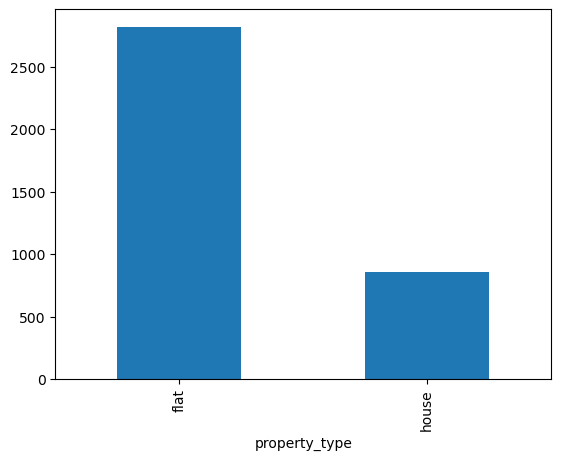

In [10]:
#property_type 

df.property_type.value_counts().plot(kind = 'bar')

In [14]:
df.society.value_counts()

society
independent                             486
tulip violet                             75
ss the leaf                              73
shapoorji pallonji joyville gurugram     42
dlf new town heights                     42
                                       ... 
raheja atlantis                           1
swarn jayanti cghs                        1
signature global orchard avenue 2         1
bajrang apartments                        1
maruti vihar colony                       1
Name: count, Length: 677, dtype: int64

In [15]:
df[df.society != 'independent']['society'].value_counts(normalize = 'True').cumsum().head(75)

society
tulip violet                            0.023504
ss the leaf                             0.046380
dlf new town heights                    0.059542
shapoorji pallonji joyville gurugram    0.072704
signature global park                   0.083673
                                          ...   
ramsons kshitij                         0.490442
dlf the primus                          0.494516
the close north                         0.498590
mvn athens                              0.502350
central park flower valley              0.506111
Name: proportion, Length: 75, dtype: float64

In [17]:
society_counts = df.society.value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(272),
 'Very Low (1)': np.int64(310)}

<Axes: xlabel='society'>

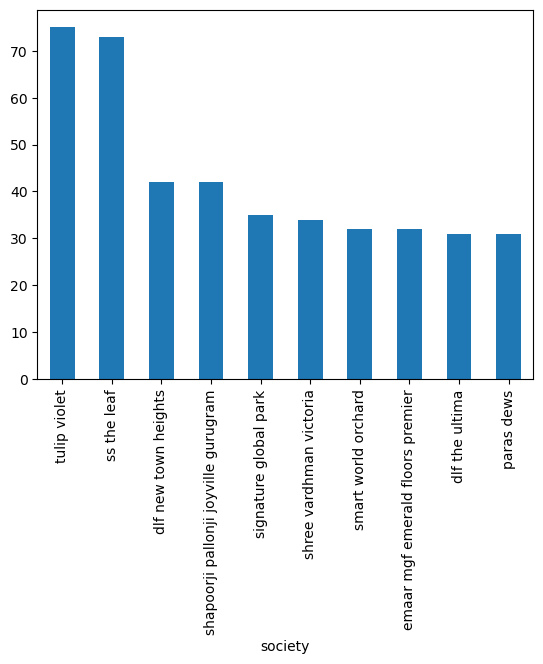

In [18]:
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [20]:
df.society.isnull().sum()

np.int64(1)

Observations
Around 13% properties comes under independent tag.
There are 675 societies.
The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
Very High (>100): Only 1 society has more than 100 listings.
High (50-100): 2 societies have between 50 to 100 listings.
Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
Low (2-9): 273 societies have between 2 to 9 listings.
Very Low (1): A significant number, 308 societies, have only 1 listing.
1 missing value

In [21]:
# unique sectors
df['sector'].value_counts().shape

(115,)

<Axes: xlabel='sector'>

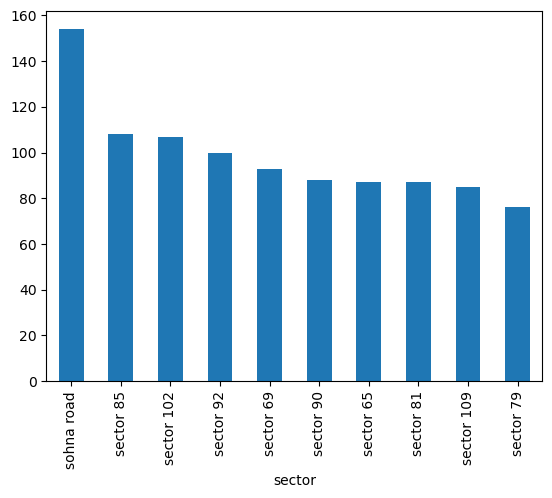

In [22]:
df['sector'].value_counts().head(10).plot(kind='bar')

In [24]:
df['price'].isnull().sum()

np.int64(17)

In [25]:
df['price'].describe()

count    3661.000000
mean        2.533286
std         2.980304
min         0.070000
25%         0.950000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

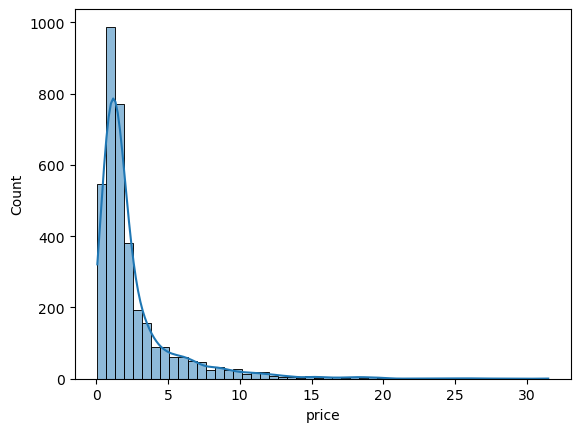

In [26]:
sns.histplot(df['price'], kde=True, bins=50)

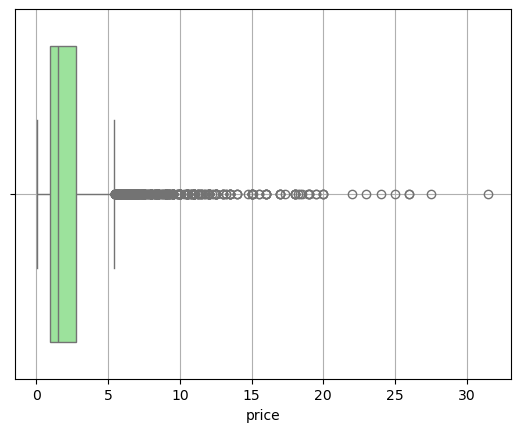

In [28]:
sns.boxplot(x=df['price'], color='lightgreen')
plt.grid()

#observations

- **Count:** 3660
- **Mean:** ₹2.53 Cr
- **Median:** ₹1.52 Cr
- **Standard Deviation:** ₹2.98 Cr
- **Range:** ₹0.07 Cr – ₹31.5 Cr
- **IQR:** ₹0.95 Cr – ₹2.75 Cr

Descriptive Statistics:

    Count: There are 3,660 non-missing price entries.
    Mean Price: The average price is approximately 2.53 crores.
    
    Median Price: The median (or 50th percentile) price is 1.52 crores.
    Standard Deviation: The prices have a standard deviation of 2.98, indicating variability in the prices.

    Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.

    IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.95 crores to 2.75 crores.
    Visualizations:

Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
    
    Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might       be considered outliers as they lie beyond the upper whisker of the box plot.
    
    Missing Values: There are 17 missing values in the price column.

In [29]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.279681711956382 14.937832687555824


In [ ]:
Skewness: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

Kurtosis: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [30]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.25
0.05     0.37
0.95     8.50
0.99    15.26
Name: price, dtype: float64

Quantile Analysis:

1% Quantile: Only 1% of properties are priced below 0.25 crores.
5% Quantile: 5% of properties are priced below 0.37 crores.
95% Quantile: 95% of properties are priced below 8.5 crores.
99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [32]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.8)

In [33]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.7500000000000002 5.45


In [34]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(425, 23)

In [35]:
outliers['price'].describe()

count    425.000000
mean       9.235624
std        4.065259
min        5.460000
25%        6.460000
50%        8.000000
75%       10.750000
max       31.500000
Name: price, dtype: float64

Outliers Analysis (using IQR method):

    Based on the IQR method, there are 425 properties considered as outliers.
    These outliers have an average price of approximately 9.24 crores.
    The range for these outliers is from 5.46 crores to 31.5 crores.

<Axes: xlabel='price'>

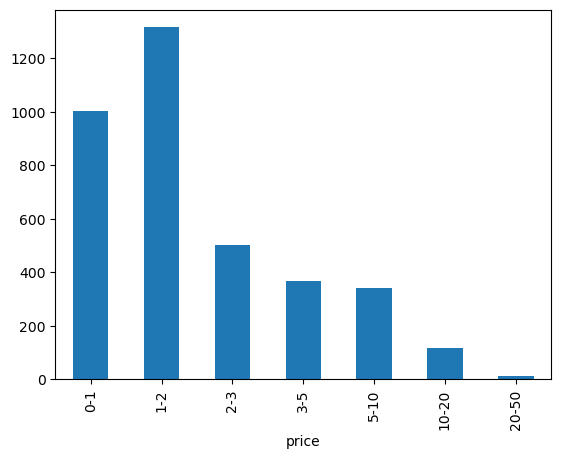

In [36]:
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

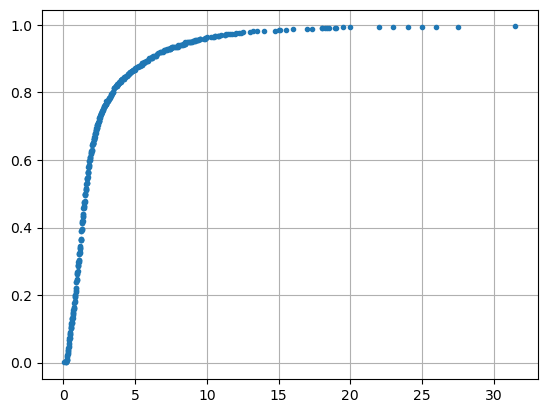

In [37]:
# ecdf plot
ecdf = df['price'].value_counts().sort_index().cumsum() / len(df['price'])
plt.plot(ecdf.index, ecdf, marker='.', linestyle='none')
plt.grid()

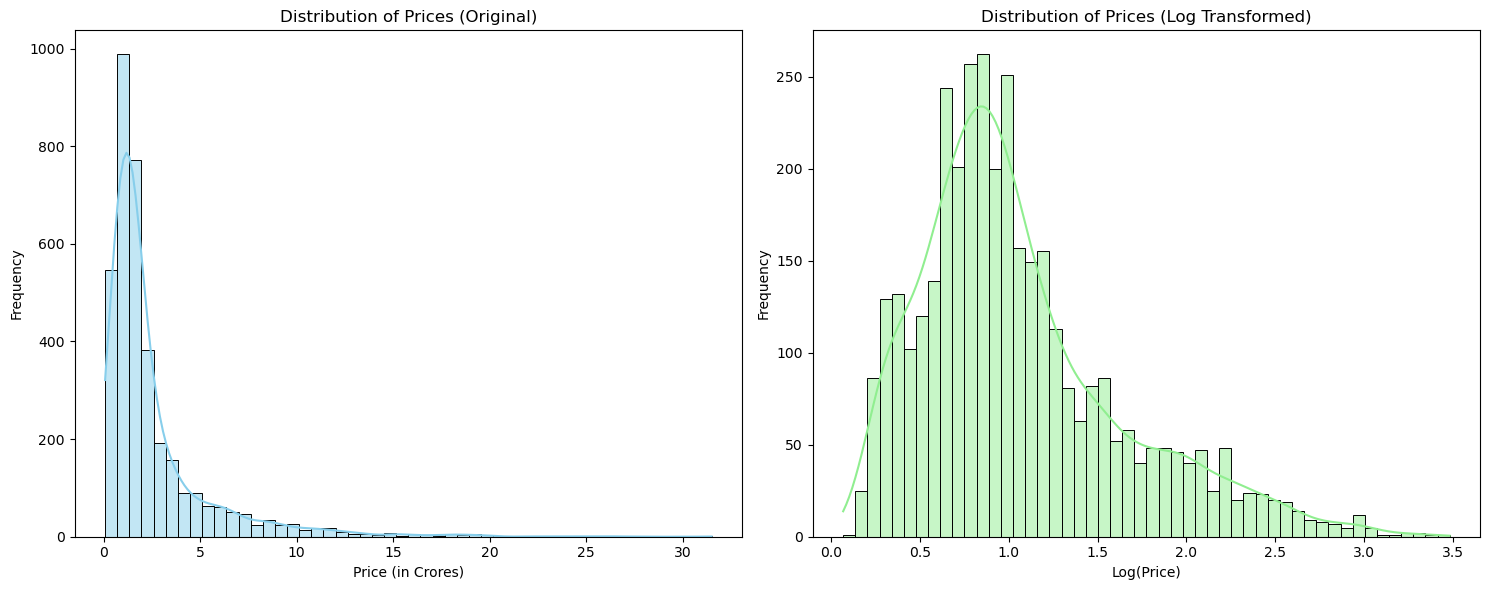

In [38]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [39]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0744845403467573 0.9658086480547525


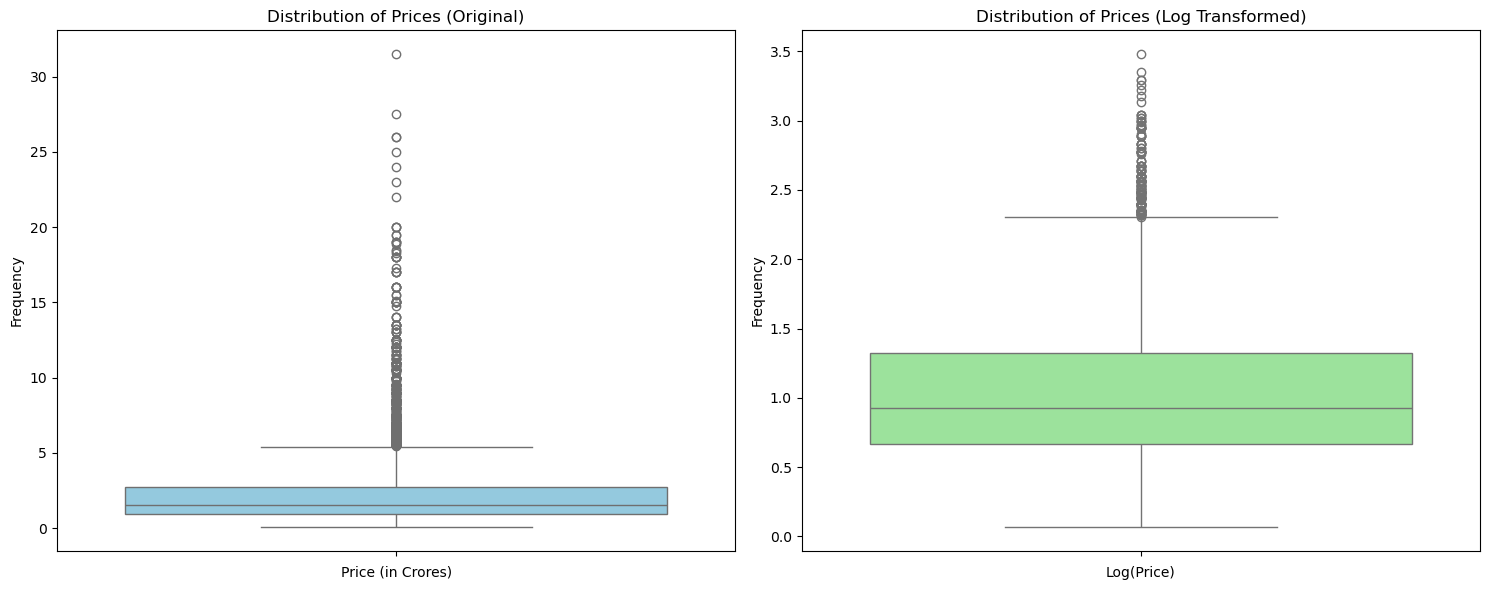

In [40]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [41]:
df['price_per_sqft'].isnull().sum()

np.int64(17)

In [42]:
df['price_per_sqft'].describe()

count      3661.000000
mean      13890.316853
std       23207.332335
min           4.000000
25%        6815.000000
50%        9020.000000
75%       13878.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

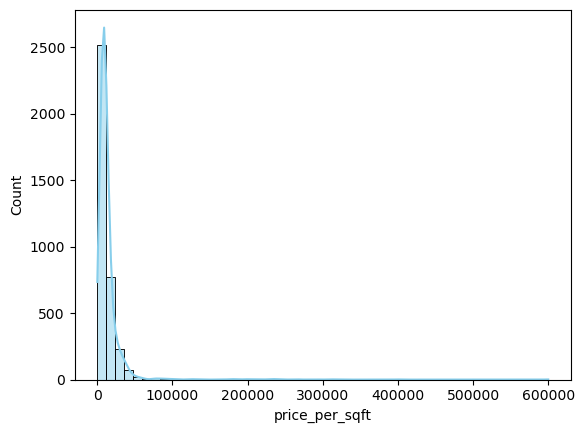

In [43]:
sns.histplot(df['price_per_sqft'], bins=50, color='skyblue', kde=True)

<Axes: ylabel='price_per_sqft'>

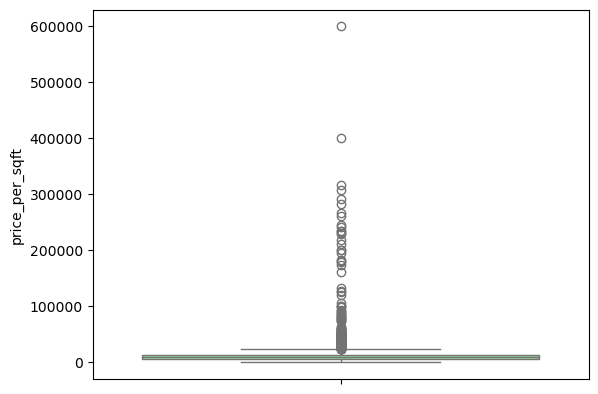

In [47]:
sns.boxplot(df['price_per_sqft'], color='lightgreen' )

Observations :
    
    Potential Outliers
    
    Right Skewed
    
    17 missing values

In [48]:
df['bedRoom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bedRoom'>

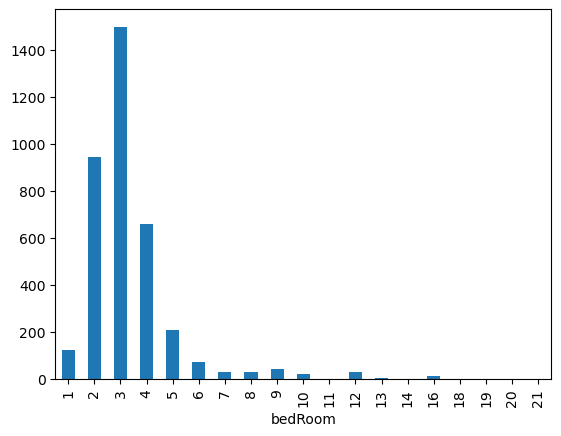

In [49]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

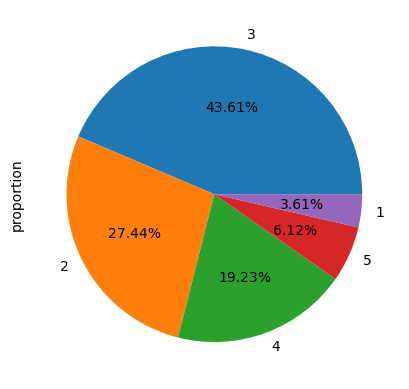

In [50]:
df['bedRoom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [51]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

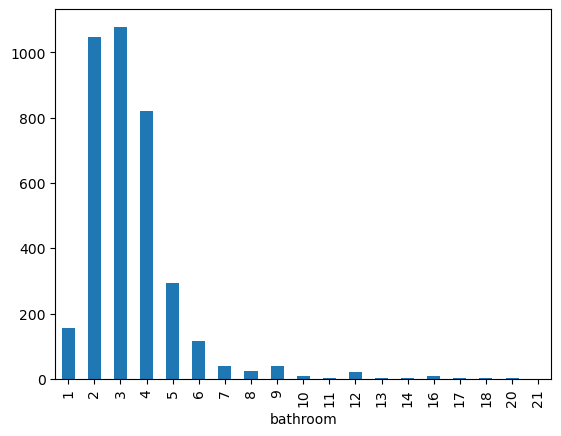

In [52]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='proportion'>

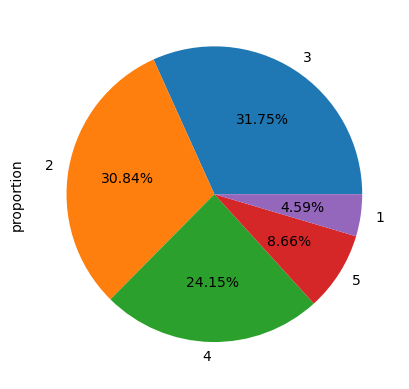

In [53]:
df['bathroom'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [54]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,3.0,...,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,1st of 1 Floors,...,NaN,602.0,NaN,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,4th of 19 Floors,...,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,8th of 14 Floors,...,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2nd of 17 Floors,...,2200.0,NaN,NaN,0,1,0,0,0,2,123


In [55]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

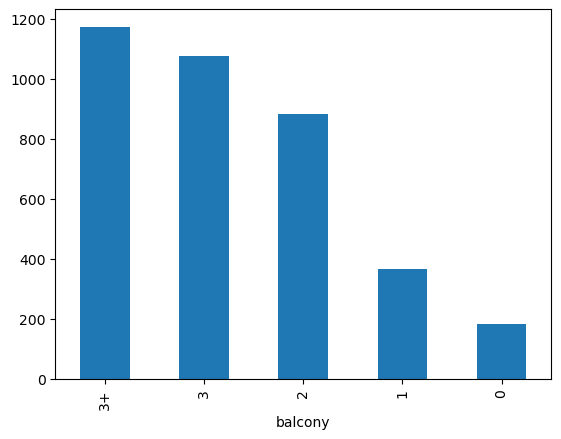

In [56]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='proportion'>

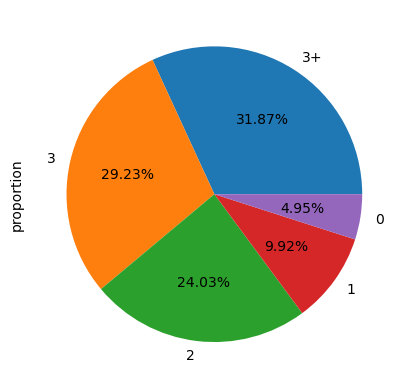

In [57]:
df['balcony'].value_counts(normalize=True).head().plot(kind='pie',autopct='%0.2f%%')

In [ ]:
### floorNum

In [58]:
df.iloc[:,10:].head()

,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,East,Moderately Old,house,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,NaN,Undefined,flat,NaN,602.0,NaN,0,0,0,0,0,0,0
2,NaN,Relatively New,flat,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,NaN,Relatively New,flat,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,South-East,Moderately Old,flat,2200.0,NaN,NaN,0,1,0,0,0,2,123


In [59]:
df['floorNum'].isnull().sum()

np.int64(19)

In [60]:
df['floorNum'].describe()

count     3659
unique     568
top        3.0
freq       273
Name: floorNum, dtype: object

In [72]:
df.floorNum.head()

0                   3.0
1     1st   of 1 Floors
2    4th   of 19 Floors
3    8th   of 14 Floors
4    2nd   of 17 Floors
Name: floorNum, dtype: object

In [73]:

df['facing'].isnull().sum()

np.int64(1046)

In [74]:
df['agePossession'].isnull().sum()

np.int64(0)

In [75]:
df['agePossession'].value_counts()

agePossession
Relatively New        1646
New Property           593
Moderately Old         564
Undefined              306
Old Property           303
Under Construction     266
Name: count, dtype: int64

In [76]:
df.columns

Index(['society', 'price', 'sector', 'price_per_sqft', 'area', 'areaWithType',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'facing', 'agePossession',
       'property_type', 'super_built_up_area', 'built_up_area', 'carpet_area',
       'study room', 'servant room', 'store room', 'pooja room', 'others',
       'furnishing_type', 'luxury_score'],
      dtype='object')

In [77]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1802)

In [78]:
df['super_built_up_area'].describe()

count     1876.000000
mean      1925.371295
std        763.990307
min         89.000000
25%       1479.750000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

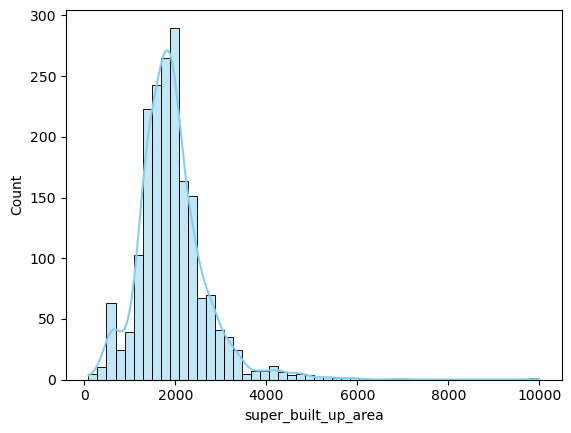

In [79]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: xlabel='super_built_up_area'>

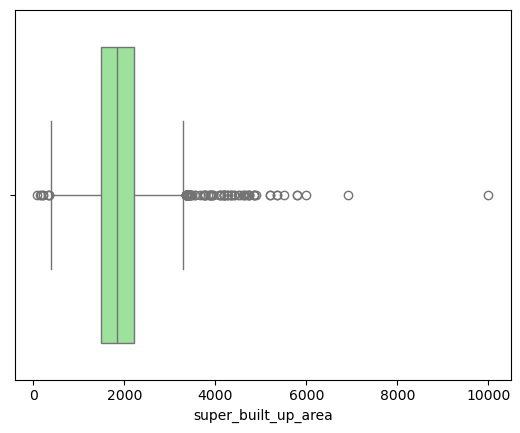

In [82]:
sns.boxplot(data=df, x="super_built_up_area", color="lightgreen")

Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
There are a few properties with a significantly larger area, leading to a right-skewed distribution.
The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [83]:
# built up area
df['built_up_area'].isnull().sum()

np.int64(1988)

In [84]:
df['built_up_area'].describe()

count      1690.000000
mean       2379.585816
std       17942.880237
min           2.000000
25%        1100.000000
50%        1650.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

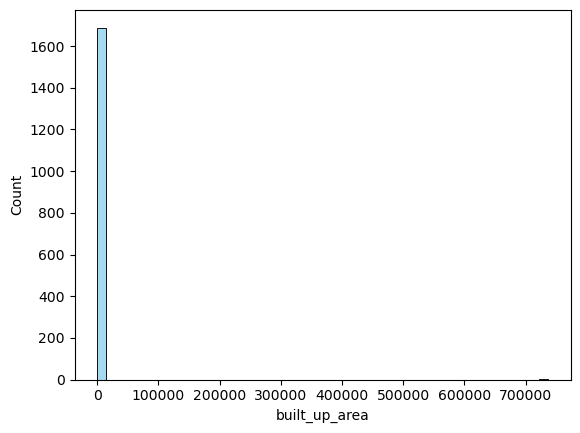

In [85]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: ylabel='built_up_area'>

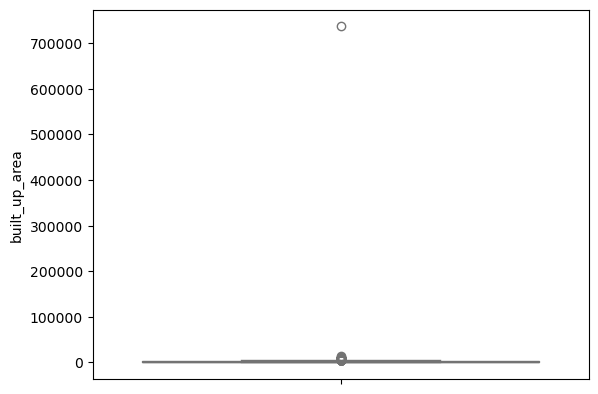

In [86]:
sns.boxplot(df['built_up_area'].dropna(), color='lightgreen')

In [ ]:
Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.
The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [87]:
df['carpet_area'].isnull().sum()

np.int64(1806)

In [88]:
df['carpet_area'].describe()

count      1872.000000
mean       2529.179507
std       22799.836449
min          15.000000
25%         843.000000
50%        1300.000000
75%        1790.000000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

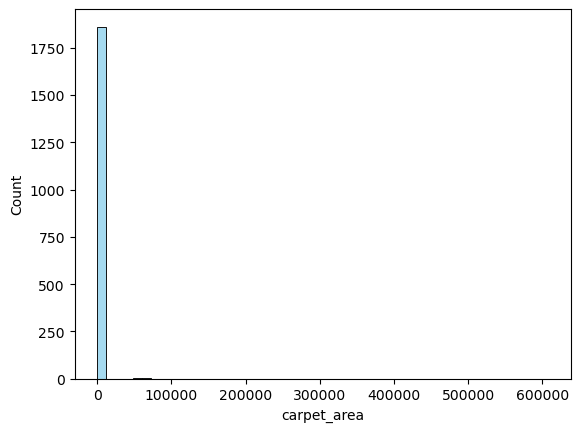

In [89]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

In [90]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,1,1,1,1,0,0,76
1,0,0,0,0,0,0,0
2,0,0,0,0,0,0,56
3,0,0,0,0,0,0,46
4,0,1,0,0,0,2,123
5,1,0,0,0,1,0,90
6,0,0,0,1,0,2,145
7,0,0,0,0,0,2,103
8,1,0,0,0,1,0,61
9,0,0,0,0,0,0,0


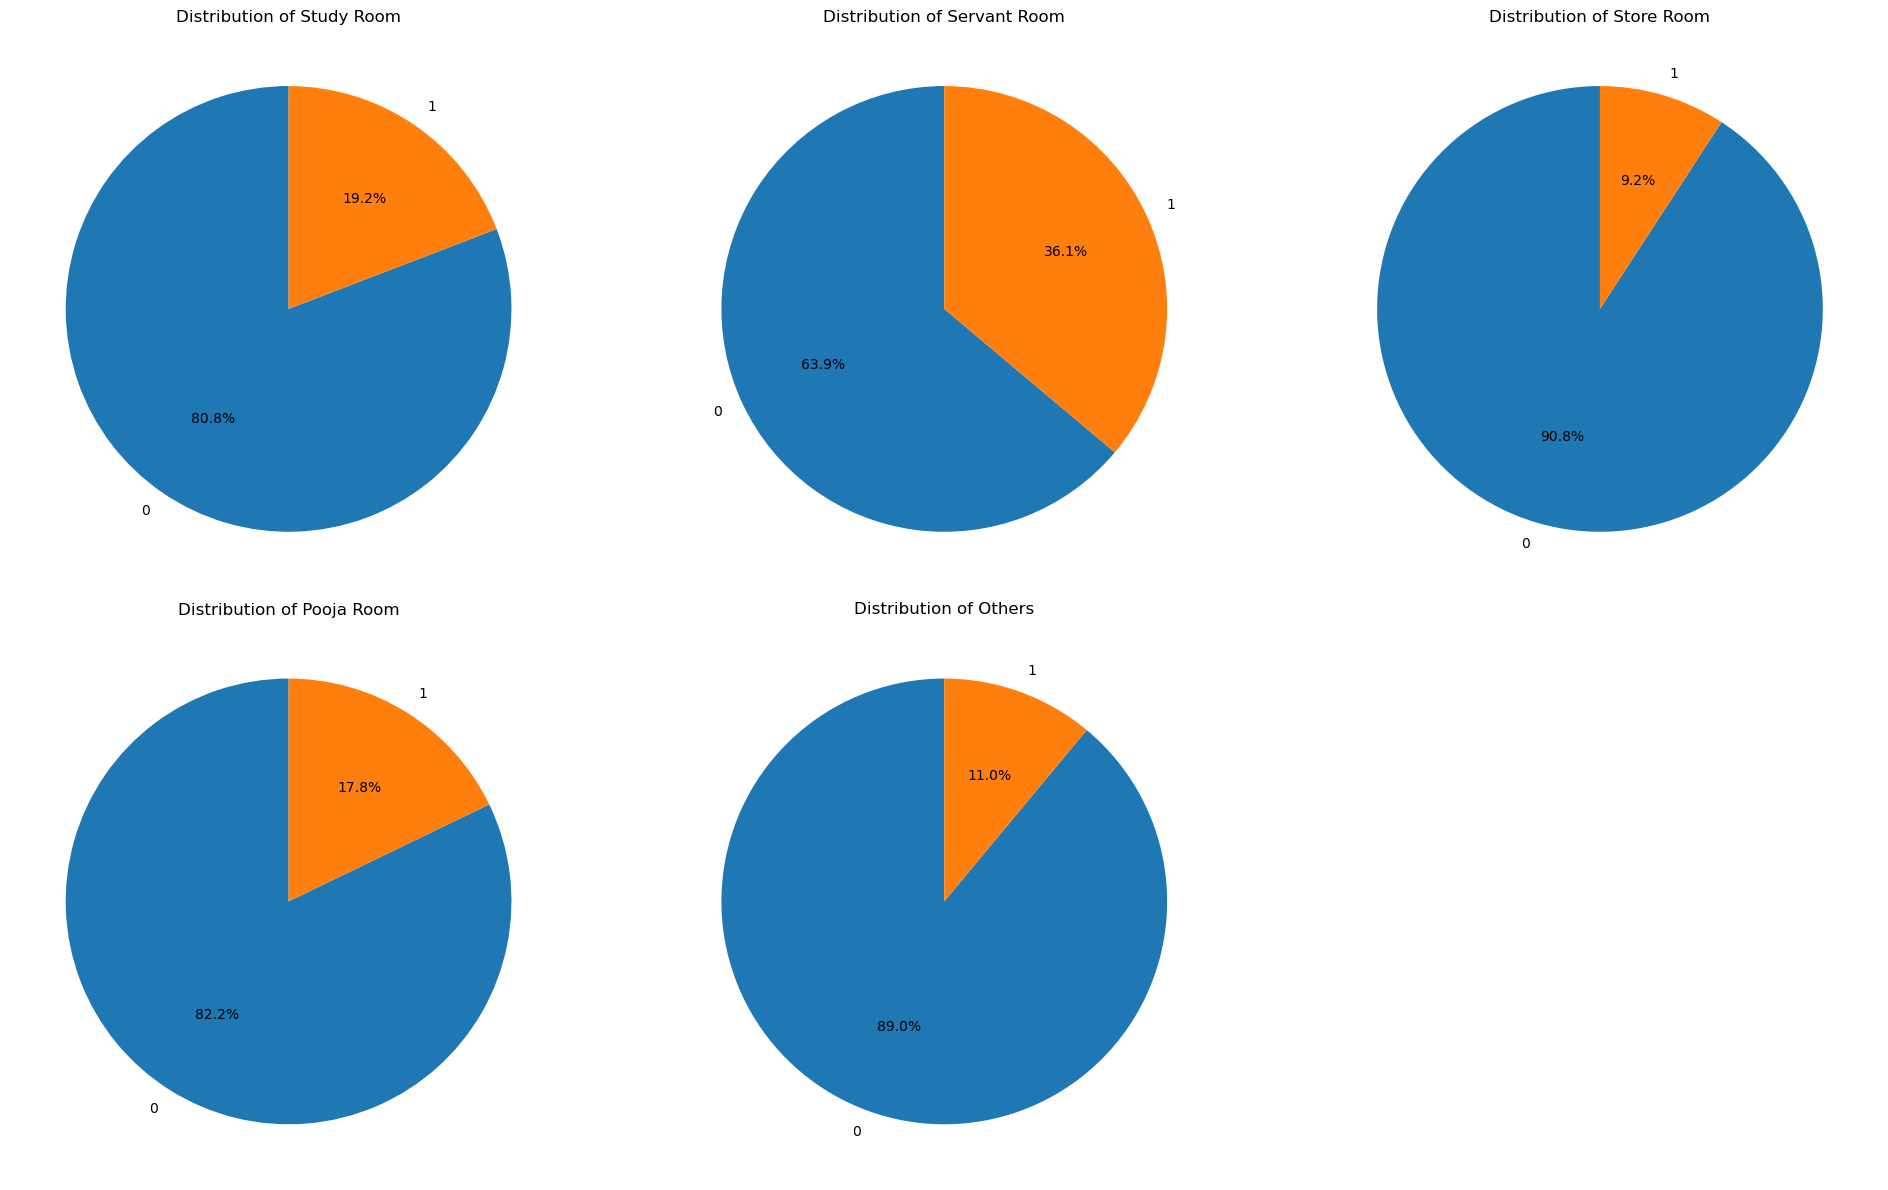

In [91]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

In [92]:
df['furnishing_type'].value_counts()

furnishing_type
0    2405
2    1061
1     212
Name: count, dtype: int64

<Axes: ylabel='count'>

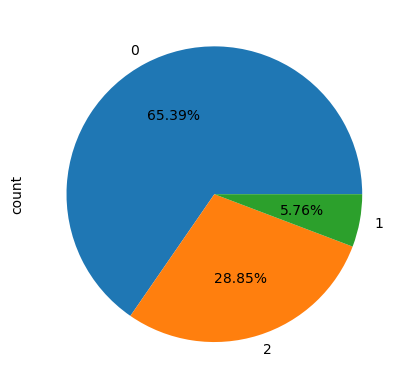

In [93]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [94]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [95]:
df['luxury_score'].describe()

count    3678.000000
mean       71.499456
std        53.058148
min         0.000000
25%        31.000000
50%        59.000000
75%       110.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

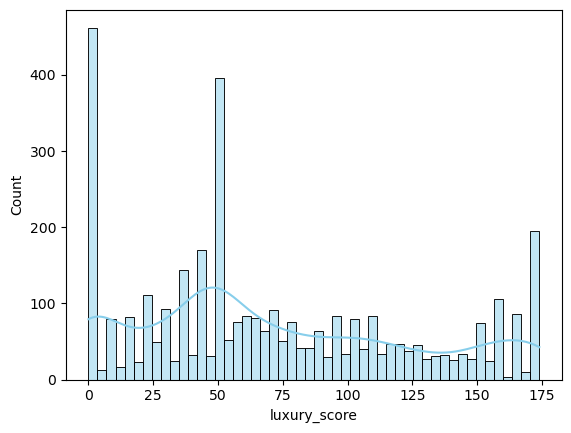

In [96]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: xlabel='luxury_score'>

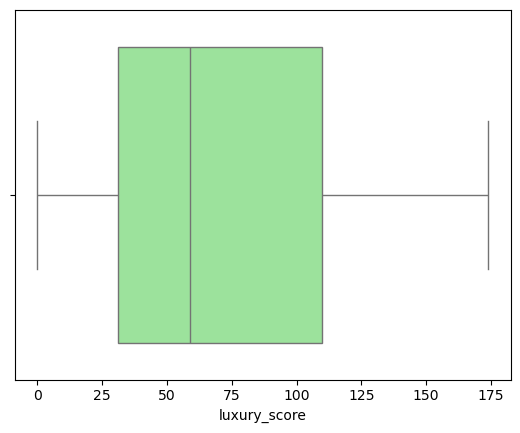

In [97]:
sns.boxplot(data = df, x = 'luxury_score' ,color='lightgreen')

In [ ]:

The luxury score distribution has multiple peaks, suggesting a multi-modal distribution. There's a significant number of properties with lower luxury scores (around 0-50), and another peak is observed around the 110-130 range.

The box plot reveals that the majority of the properties have luxury scores between approximately 30 and 110. The interquartile range (IQR) lies between these values.

In [98]:
df.head()

,society,price,sector,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,floorNum,facing,agePossession,property_type,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,independent,15.50,sector 43,28233.0,5490.00,Plot area 610(510.04 sq.m.),5,6,3,3.0,East,Moderately Old,house,NaN,5490.0,NaN,1,1,1,1,0,0,76
1,trisara our homes 3,0.38,sohna road,6312.0,602.03,Built Up area: 602 (55.93 sq.m.),2,2,2,1st of 1 Floors,NaN,Undefined,flat,NaN,602.0,NaN,0,0,0,0,0,0,0
2,sare green parc phase 3,0.70,sector 92,5279.0,1326.01,Super Built up area 1326(123.19 sq.m.)Built Up...,3,2,2,4th of 19 Floors,NaN,Relatively New,flat,1326.0,1325.0,1320.00,0,0,0,0,0,0,56
3,emaar gurgaon greens,1.60,sector 102,9696.0,1650.17,Super Built up area 1650(153.29 sq.m.)Carpet a...,3,3,3,8th of 14 Floors,NaN,Relatively New,flat,1650.0,NaN,1022.58,0,0,0,0,0,0,46
4,emaar mgf the palm drive,3.98,sector 66,18090.0,2200.11,Super Built up area 2200(204.39 sq.m.),3,4,3+,2nd of 17 Floors,South-East,Moderately Old,flat,2200.0,NaN,NaN,0,1,0,0,0,2,123
